# LeetCode #200: Number of Islands

https://leetcode.com/problems/number-of-islands/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| DFS Flood Fill ★ | O(m×n) | O(m×n) |
| BFS Flood Fill | O(m×n) | O(min(m,n)) |
| Union-Find | O(m×n × α(m×n)) | O(m×n) |

## Understanding the Methods
### DFS Flood Fill (Optimal)
Iterate through the grid. When a '1' is found, increment the island count and perform a DFS to mark all connected '1' cells as visited (by changing them to '0'). Each cell is visited at most once, giving O(m×n) time.

### BFS Flood Fill
Same logic as DFS but uses a queue for breadth-first traversal. The space is bounded by the smaller dimension since the BFS frontier can grow at most to min(m,n) in a grid.

### Union-Find
Treat each '1' cell as a node. Union adjacent '1' cells. The number of distinct roots at the end is the number of islands. Uses path compression and union by rank for near-constant amortized operations.

## Solutions

### C#

In [ ]:
public class Solution {
    public int NumIslands(char[][] grid) {
        int m = grid.Length, n = grid[0].Length;
        int count = 0;
        for (int i = 0; i < m; i++) {
            for (int j = 0; j < n; j++) {
                if (grid[i][j] == '1') {
                    count++;
                    Dfs(grid, i, j, m, n);
                }
            }
        }
        return count;
    }
    
    private void Dfs(char[][] grid, int i, int j, int m, int n) {
        if (i < 0 || i >= m || j < 0 || j >= n || grid[i][j] != '1') return;
        grid[i][j] = '0';
        Dfs(grid, i + 1, j, m, n);
        Dfs(grid, i - 1, j, m, n);
        Dfs(grid, i, j + 1, m, n);
        Dfs(grid, i, j - 1, m, n);
    }
}

### Python

In [ ]:
class Solution:
    def numIslands(self, grid: list[list[str]]) -> int:
        if not grid:
            return 0
        m, n = len(grid), len(grid[0])
        count = 0

        def dfs(i: int, j: int) -> None:
            if i < 0 or i >= m or j < 0 or j >= n or grid[i][j] != '1':
                return
            grid[i][j] = '0'
            dfs(i + 1, j)
            dfs(i - 1, j)
            dfs(i, j + 1)
            dfs(i, j - 1)

        for i in range(m):
            for j in range(n):
                if grid[i][j] == '1':
                    count += 1
                    dfs(i, j)
        return count

### Go

In [ ]:
func numIslands(grid [][]byte) int {
    m := len(grid)
    if m == 0 {
        return 0
    }
    n := len(grid[0])
    count := 0

    var dfs func(i, j int)
    dfs = func(i, j int) {
        if i < 0 || i >= m || j < 0 || j >= n || grid[i][j] != '1' {
            return
        }
        grid[i][j] = '0'
        dfs(i+1, j)
        dfs(i-1, j)
        dfs(i, j+1)
        dfs(i, j-1)
    }

    for i := 0; i < m; i++ {
        for j := 0; j < n; j++ {
            if grid[i][j] == '1' {
                count++
                dfs(i, j)
            }
        }
    }
    return count
}

### Rust

In [ ]:
impl Solution {
    pub fn num_islands(mut grid: Vec<Vec<char>>) -> i32 {
        let m = grid.len();
        if m == 0 { return 0; }
        let n = grid[0].len();
        let mut count = 0;
        for i in 0..m {
            for j in 0..n {
                if grid[i][j] == '1' {
                    count += 1;
                    Self::dfs(&mut grid, i as i32, j as i32, m as i32, n as i32);
                }
            }
        }
        count
    }

    fn dfs(grid: &mut Vec<Vec<char>>, i: i32, j: i32, m: i32, n: i32) {
        if i < 0 || i >= m || j < 0 || j >= n || grid[i as usize][j as usize] != '1' {
            return;
        }
        grid[i as usize][j as usize] = '0';
        Self::dfs(grid, i + 1, j, m, n);
        Self::dfs(grid, i - 1, j, m, n);
        Self::dfs(grid, i, j + 1, m, n);
        Self::dfs(grid, i, j - 1, m, n);
    }
}

## Example Scenarios

### 1. Common Case — Single Connected Island
**Input:** `grid = [["1","1","1"],["0","1","0"],["1","1","1"]]`

All land cells connect through the center column. DFS from (0,0) floods the entire grid in one pass. **Output:** `1`

### 2. Slightly Complex — Multiple Disconnected Islands
**Input:** `grid = [["1","0","0","1"],["0","0","0","0"],["0","0","0","0"],["1","0","0","1"]]`

Four corner cells, each isolated by water. Each triggers a separate DFS that terminates immediately (single-cell island). **Output:** `4`

### 3. Edge Case: Time Factor — Full Grid of Land (Worst-Case DFS Depth)
**Input:** `grid` = 300$\times$300 all `"1"`s

DFS from (0,0) visits all 90,000 cells in one call. Recursion depth reaches $m \times n = 90{,}000$, risking stack overflow in languages with small default stacks. Iterative BFS with an explicit queue avoids this. **Output:** `1`

### 4. Edge Case: Space Factor — Checkerboard Pattern (Maximum Islands)
**Input:** `grid = [["1","0","1","0"],["0","1","0","1"],["1","0","1","0"],["0","1","0","1"]]`

No two land cells share an edge — each is its own island. Produces $\lceil m \times n / 2 \rceil = 8$ separate DFS calls, each using $O(1)$ stack space but the scan itself is still $O(m \times n)$. **Output:** `8`

### 5. Almost-Impossible but Plausible — 1×1 Grid and Empty Grid
**Input A:** `grid = [["1"]]` → `1`  |  **Input B:** `grid = [["0"]]` → `0`  |  **Input C:** `grid = []` → `0`

Boundary checks interviewers use as follow-ups: empty grid returns 0 immediately (guard clause), 1×1 grid tests the base case without any recursion. These verify defensive coding and null handling — a common Google interview probe.

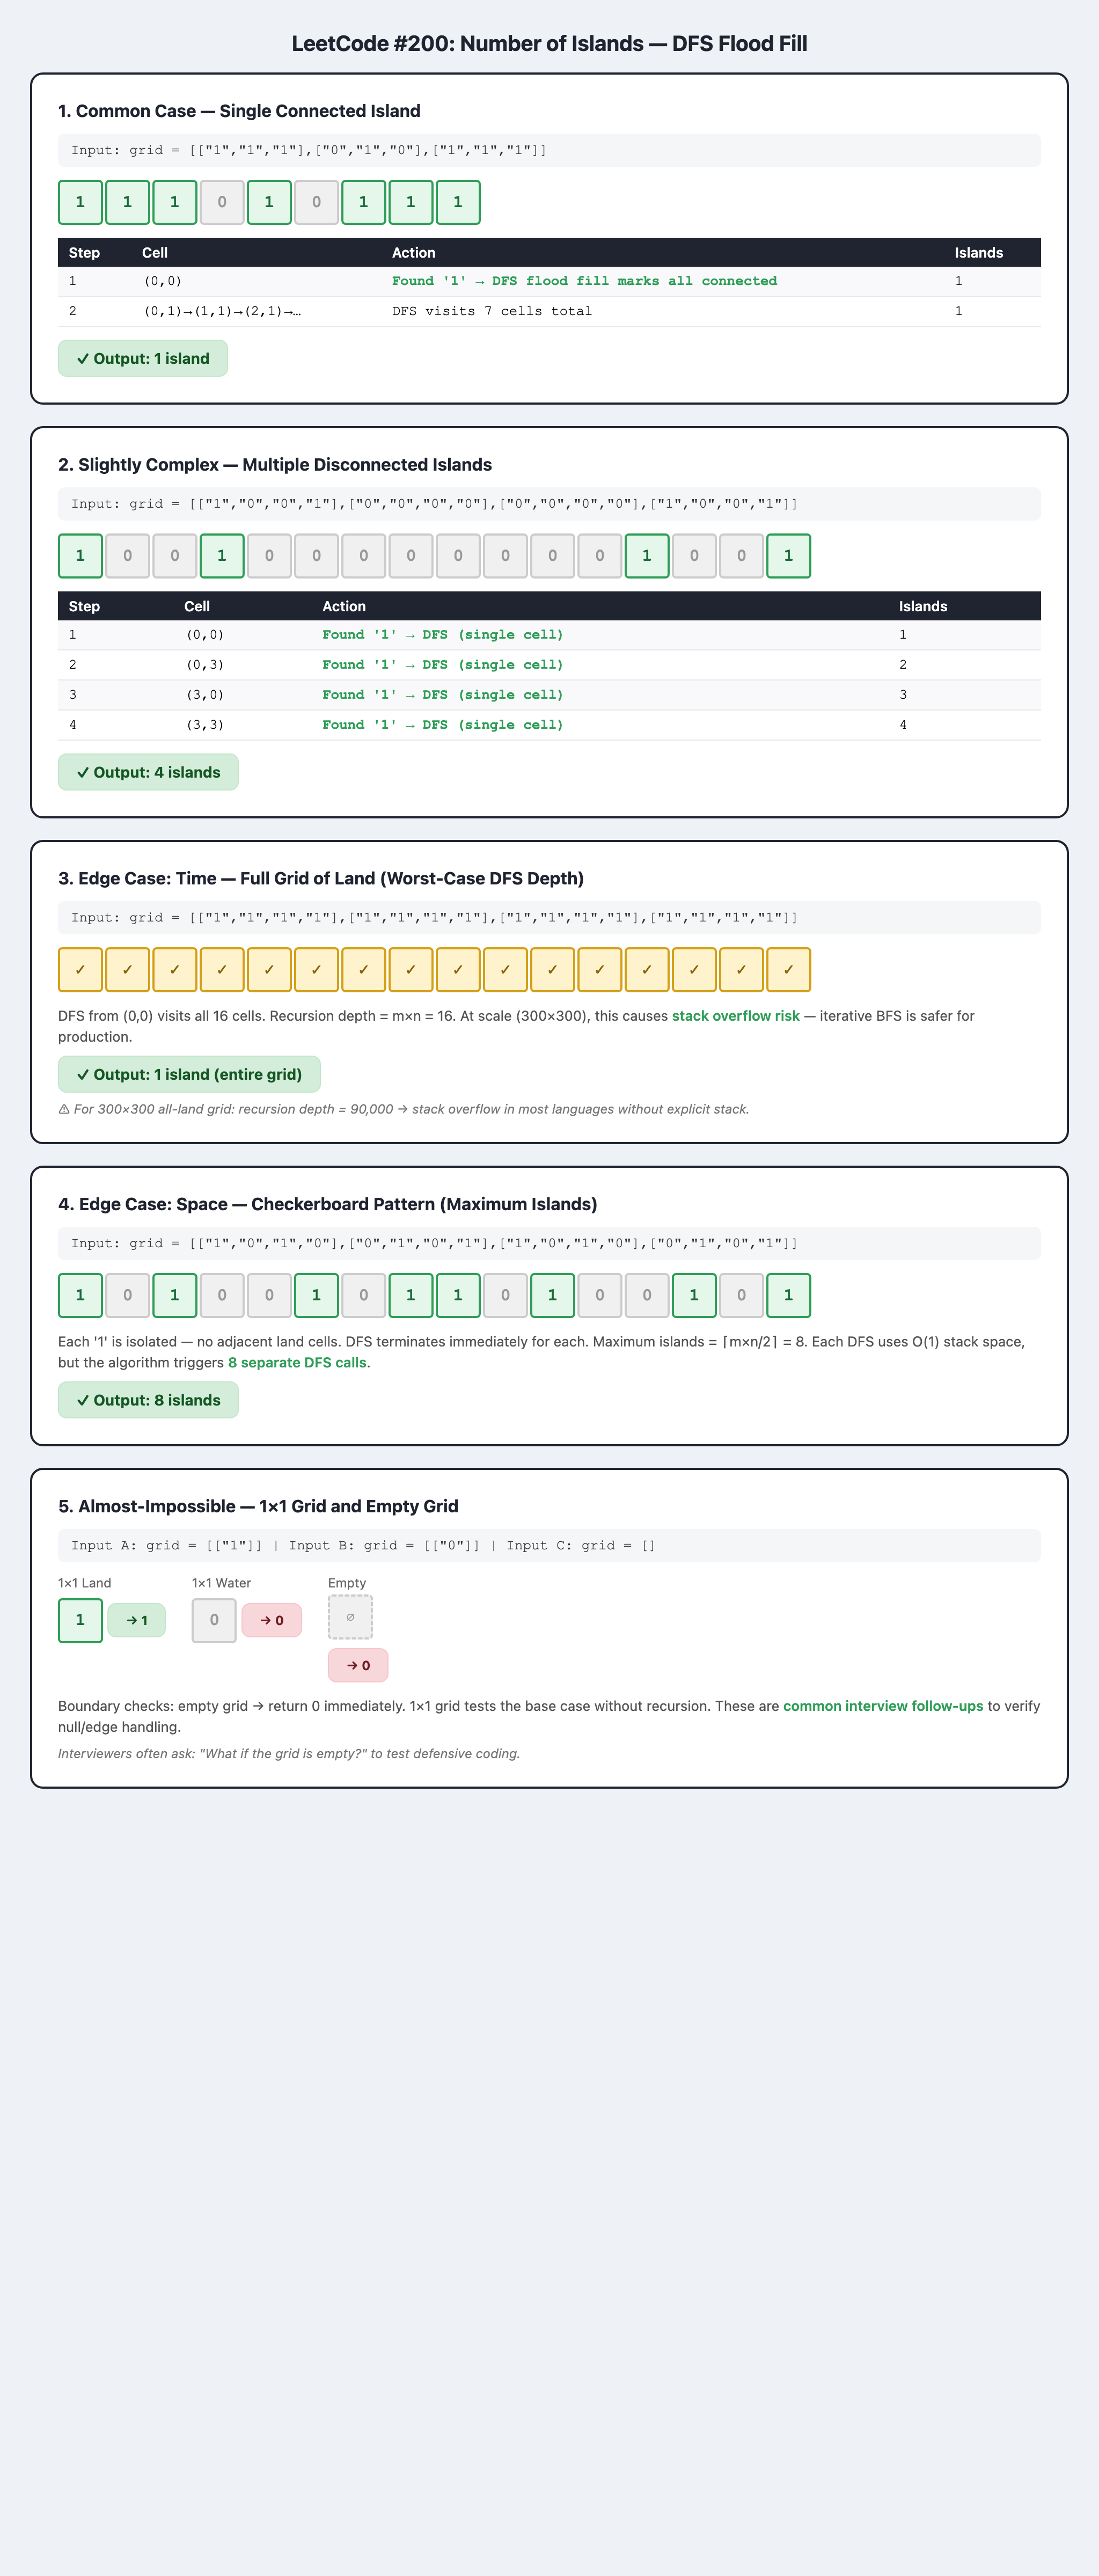